# LSM Initialisation for ECG — 3-Fold Composite Fitness Notebook

This notebook implements the clean ECG version of the LSM initialisation experiment.

The method is:

```text
BO / GA / ES optimiser → 15-parameter LSM initialisation → fixed-STDP LSM training → Ridge/L2 evaluation → composite fitness
```

The **primary signal is macro F1**, but CER and MSE also affect the search with smaller weights.

Composite score used by BO/GA/ES:

```text
score = 0.70 × macro_F1 + 0.20 × (1 - CER) + 0.10 × (1 / (1 + MSE))
```

Higher score is better. This means the optimiser mainly searches for high F1, but it is also rewarded for lower CER and lower MSE.


## 1. Imports, Reproducibility, and Permission-Safe Paths

This cell imports the libraries used by the ECG LSM initialisation experiment and creates writable output locations.

The permission-safe path logic is included because some university/Linux environments block writing to the current project directory. The code tries multiple locations and uses the first one that can actually be written to. This prevents errors such as:

```text
PermissionError: [Errno 13] Permission denied
```

The output folders are used for cached fitness values, checkpoints, saved optimiser results, and final JSON files.

In [15]:
# ============================================================
# 1. Imports and safe writable paths
# ============================================================
import os, json, gc, time, math, hashlib, warnings, traceback
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Any, List, Tuple, Optional

import numpy as np

warnings.filterwarnings("ignore")

# Optional plotting
import matplotlib.pyplot as plt

# Optional table display
try:
    import pandas as pd
    from IPython.display import display
    PANDAS_AVAILABLE = True
except Exception:
    PANDAS_AVAILABLE = False


from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# NEST import
try:
    import nest
    nest.set_verbosity("M_ERROR")
    NEST_AVAILABLE = True
except Exception as e:
    NEST_AVAILABLE = False
    print("WARNING: NEST could not be imported in this kernel.")
    print("Run this notebook inside your NEST environment.")
    print("Import error:", e)

def pick_writable_dir(preferred_name="OPT_ECG_MYINIT_3FOLD_MEMORY_SAFE_AUTORUN"):
    """
    Pick a writable output directory.
    This avoids PermissionError when the notebook is opened in a read-only folder.
    """
    candidates = [
        Path.cwd() / preferred_name,
        Path.home() / preferred_name,
        Path.home() / "PycharmProjects" / preferred_name,
        Path("/tmp") / preferred_name,
    ]
    for p in candidates:
        try:
            p.mkdir(parents=True, exist_ok=True)
            test = p / ".write_test"
            test.write_text("ok")
            test.unlink(missing_ok=True)
            return p.resolve()
        except Exception:
            continue
    raise PermissionError("Could not find any writable directory. Try running the notebook from your home folder.")

DATASET_NAME = "ECG"
OUTPUT_ROOT = pick_writable_dir("OPT_ECG_MYINIT_3FOLD_MEMORY_SAFE_AUTORUN")
CACHE_DIR = OUTPUT_ROOT / "fitness_cache"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
DATA_CACHE_DIR = OUTPUT_ROOT / "datasets_cache"
for d in [CACHE_DIR, CHECKPOINT_DIR, DATA_CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Writable OUTPUT_ROOT:", OUTPUT_ROOT)
print("Fitness cache:", CACHE_DIR)
print("Dataset cache:", DATA_CACHE_DIR)

Writable OUTPUT_ROOT: /home/ntu-user/PycharmProjects/IEEE/IEEE_6/OPT_ECG_MYINIT_3FOLD_MEMORY_SAFE_AUTORUN
Fitness cache: /home/ntu-user/PycharmProjects/IEEE/IEEE_6/OPT_ECG_MYINIT_3FOLD_MEMORY_SAFE_AUTORUN/fitness_cache
Dataset cache: /home/ntu-user/PycharmProjects/IEEE/IEEE_6/OPT_ECG_MYINIT_3FOLD_MEMORY_SAFE_AUTORUN/datasets_cache


## 2. Runtime Controls

This cell controls how expensive the notebook run will be.

`FAST_MODE=True` should be used first to confirm that the pipeline works without exhausting RAM. In fast mode the notebook uses smaller optimiser settings and shorter LSM training.

`FAST_MODE=False` is for a fuller experiment, but it still keeps **3-fold cross-validation** to reduce memory usage compared with 5-fold CV.

The optimisers do not train for epochs themselves. BO/GA/ES generate candidate initialisations; each candidate is evaluated by training the LSM for `OPT_EPOCHS`. Final training uses `FINAL_EPOCHS`.

In [16]:
# ============================================================
# 2. Runtime controls
# ============================================================

# Keep FAST_MODE=True until the full pipeline runs.
# Set FAST_MODE=False later for fuller experiments, still using 3-fold CV.
FAST_MODE = True

# User requested auto-run enabled.
# If you run all cells, BO/GA/ES cells will run with these small FAST settings.
AUTO_RUN_OPTIMISERS = True

# Plot/report controls. These create visual outputs after each optimiser finishes.
SHOW_PLOTS_AFTER_EACH_RUN = True
SAVE_PLOTS = True
PLOT_RASTER_AFTER_EACH_RUN = True  # set False if raster plotting becomes slow/heavy
RASTER_SAMPLE_INDEX = 0
RASTER_MAX_TIME_STEPS = 200

CV_FOLDS = 3  # memory-safe compromise
SEED = 42

# Composite fitness weights. F1 is primary; CER/MSE still affect the search.
FITNESS_F1_WEIGHT = 0.70
FITNESS_CER_WEIGHT = 0.20
FITNESS_MSE_WEIGHT = 0.10

if FAST_MODE:
    N_RES_DEFAULT = 50
    OPT_EPOCHS = 1
    FINAL_EPOCHS = 2

    BO_CALLS = 6
    GA_GENERATIONS = 2
    GA_POP = 4
    ES_GENERATIONS = 2
    ES_POP = 4

    # Use smaller training subset during fitness to avoid RAM/time explosions.
    MAX_TRAIN_SEQS_FOR_OPT = 60
else:
    N_RES_DEFAULT = 200
    OPT_EPOCHS = 3
    FINAL_EPOCHS = 10

    BO_CALLS = 30      # can increase to 50 if stable
    GA_GENERATIONS = 10
    GA_POP = 8
    ES_GENERATIONS = 10
    ES_POP = 8

    MAX_TRAIN_SEQS_FOR_OPT = None

print({
    "FAST_MODE": FAST_MODE,
    "AUTO_RUN_OPTIMISERS": AUTO_RUN_OPTIMISERS,
    "CV_FOLDS": CV_FOLDS,
    "OPT_EPOCHS": OPT_EPOCHS,
    "FINAL_EPOCHS": FINAL_EPOCHS,
    "N_RES_DEFAULT": N_RES_DEFAULT,
    "FITNESS_WEIGHTS": {"F1": FITNESS_F1_WEIGHT, "1-CER": FITNESS_CER_WEIGHT, "1/(1+MSE)": FITNESS_MSE_WEIGHT},
})

{'FAST_MODE': True, 'AUTO_RUN_OPTIMISERS': True, 'CV_FOLDS': 3, 'OPT_EPOCHS': 1, 'FINAL_EPOCHS': 2, 'N_RES_DEFAULT': 50, 'FITNESS_WEIGHTS': {'F1': 0.7, '1-CER': 0.2, '1/(1+MSE)': 0.1}}


## 3. Fixed STDP Configuration

This experiment keeps the STDP learning rule fixed.

That is intentional: the contribution of this notebook is the **initialisation of the LSM**, not the optimisation of the plasticity rule. Keeping STDP fixed makes the comparison cleaner because any improvement can be attributed to the initial LSM configuration rather than changing how the network learns.

The fixed STDP values are saved to `stdp_params.json` for reproducibility, but they are not included in the BO/GA/ES search space.

In [17]:
# ============================================================
# 3. Fixed STDP constants
# ============================================================

STDP_FIXED = {
    "synapse_model": "stdp_triplet_synapse",
    "Aplus": 0.001,
    "Aminus": 0.001,
    "tau_plus": 20.0,
    "Aplus_triplet": 0.005,
    "Aminus_triplet": 0.005,
    "tau_plus_triplet": 100.0,
    "Wmax": 300.0,
}

(OUTPUT_ROOT / "stdp_params.json").write_text(json.dumps({
    "stdp": STDP_FIXED,
    "fixed": True,
    "note": "STDP parameters kept fixed to isolate the effect of LSM initialisation."
}, indent=2))

print(json.dumps(STDP_FIXED, indent=2))

{
  "synapse_model": "stdp_triplet_synapse",
  "Aplus": 0.001,
  "Aminus": 0.001,
  "tau_plus": 20.0,
  "Aplus_triplet": 0.005,
  "Aminus_triplet": 0.005,
  "tau_plus_triplet": 100.0,
  "Wmax": 300.0
}


## 4. ECG Dataset Loading

This cell loads the ECG dataset used in the reservoir-computing benchmark repository linked to the ESN/KM-ESN paper ecosystem.

The dataset is loaded from Zenodo as an `.npz` file and cached locally so it is not downloaded repeatedly.

The input is converted into shape:

```text
(N, T, F)
```

where `N` is the number of sequences, `T` is sequence length, and `F` is the number of input features. For ECG, `F=2` and there are two output classes.

In [19]:
# ============================================================
# 4. ECG dataset loading
# ============================================================

ECG_URL = "https://zenodo.org/records/10839881/files/ECG_2D.npz?download=1"

def load_ecg_dataset(cache_dir=DATA_CACHE_DIR):
    import urllib.request
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / "ECG_2D.npz"

    if not cache_path.exists():
        print("Downloading ECG dataset to:", cache_path)
        urllib.request.urlretrieve(ECG_URL, cache_path)
    else:
        print("Loading cached ECG dataset:", cache_path)

    data = np.load(cache_path, allow_pickle=True)
    print("NPZ keys:", list(data.keys()))

    def get_key(*keys):
        for k in keys:
            if k in data:
                return data[k]
        raise KeyError(f"None of keys found: {keys}. Available: {list(data.keys())}")

    Xtr = get_key("X_train", "Xtr", "x_train", "X_tr")
    Xte = get_key("X_test", "Xte", "x_test", "X_te")
    ytr = get_key("Y_train", "Ytr", "y_train", "Y_tr", "ytr")
    yte = get_key("Y_test", "Yte", "y_test", "Y_te", "yte")

    Xtr = np.asarray(Xtr, dtype=np.float32)
    Xte = np.asarray(Xte, dtype=np.float32)

    # Ensure shape (N, T, F)
    if Xtr.ndim == 2:
        Xtr = Xtr[:, :, None]
        Xte = Xte[:, :, None]
    elif Xtr.ndim == 3 and Xtr.shape[1] < Xtr.shape[2]:
        # likely (N, F, T) -> (N, T, F)
        Xtr = Xtr.transpose(0, 2, 1)
        Xte = Xte.transpose(0, 2, 1)

    # Per-sample per-feature normalisation to [0, 1], matching friend code style
    def norm01(X):
        X = X.copy()
        for i in range(len(X)):
            for f in range(X.shape[2]):
                lo = np.nanmin(X[i, :, f])
                hi = np.nanmax(X[i, :, f])
                if hi - lo > 1e-8:
                    X[i, :, f] = (X[i, :, f] - lo) / (hi - lo)
                else:
                    X[i, :, f] = 0.0
        return X.astype(np.float32)

    Xtr = norm01(Xtr)
    Xte = norm01(Xte)

    le = LabelEncoder()
    ytr = le.fit_transform(np.asarray(ytr).ravel()).astype(int)
    yte = le.transform(np.asarray(yte).ravel()).astype(int)

    n_classes = len(le.classes_)
    n_features = Xtr.shape[2]

    print(f"ECG shapes: X_train={Xtr.shape}, X_test={Xte.shape}, classes={n_classes}, features={n_features}")
    print("Train distribution:", dict(zip(*np.unique(ytr, return_counts=True))))
    print("Test distribution:", dict(zip(*np.unique(yte, return_counts=True))))
    return Xtr, ytr, Xte, yte, n_classes, n_features, le

X_train, y_train, X_test, y_test, N_CLASSES, N_FEATURES, LABEL_ENCODER = load_ecg_dataset()

Loading cached ECG dataset: /home/ntu-user/PycharmProjects/IEEE/IEEE_6/OPT_ECG_MYINIT_3FOLD_MEMORY_SAFE_AUTORUN/datasets_cache/ECG_2D.npz
NPZ keys: ['Xtr', 'Ytr', 'Xte', 'Yte']
ECG shapes: X_train=(100, 152, 2), X_test=(100, 152, 2), classes=2, features=2
Train distribution: {0: 34, 1: 66}
Test distribution: {0: 33, 1: 67}


## 5. Metrics and Utility Functions

This cell defines helper functions used throughout the notebook.

The optimiser uses a **composite fitness score**. Macro F1 is the primary component, but CER and MSE also affect the search with lower weight.

```text
composite_score = 0.70 × macro_F1 + 0.20 × (1 - CER) + 0.10 × (1 / (1 + MSE))
```

Roles:

| Metric | Role | Direction | Weight in search |
|---|---|---:|---:|
| Macro F1 | Primary optimisation signal | Higher better | 0.70 |
| CER | Secondary optimisation signal + final comparison metric | Lower better | 0.20 through `1 - CER` |
| MSE | Secondary optimisation signal for paper-style alignment | Lower better | 0.10 through `1 / (1 + MSE)` |


In [20]:
# ============================================================
# 5. Metrics and utilities
# ============================================================

def one_hot(y, n_classes):
    y = np.asarray(y).astype(int)
    out = np.zeros((len(y), n_classes), dtype=np.float32)
    out[np.arange(len(y)), y] = 1.0
    return out

def cer_score(y_true, y_pred):
    return float(np.mean(np.asarray(y_true) != np.asarray(y_pred)))

def safe_reset_nest(seed=1):
    if not NEST_AVAILABLE:
        raise RuntimeError("NEST is not available. Run inside the NEST environment.")
    try:
        nest.ResetKernel()
        nest.set_verbosity("M_ERROR")
        nest.SetKernelStatus({"print_time": False, "rng_seed": max(1, int(seed))})
    except Exception:
        nest.ResetKernel()
        nest.set_verbosity("M_ERROR")

def clear_memory():
    try:
        if NEST_AVAILABLE:
            nest.ResetKernel()
    except Exception:
        pass
    gc.collect()

def stable_hash(obj):
    s = json.dumps(obj, sort_keys=True, default=str)
    return hashlib.md5(s.encode()).hexdigest()

## 6. LSM Initialisation Search Space

This cell defines the parameter search space for the proposed method.

The key idea is that BO, GA, and ES optimise a candidate LSM initialisation. The STDP rule stays fixed.

In full mode the method optimises 15 LSM initialisation parameters, including reservoir size, number of driven neurons, input scaling, recurrent/readout indegrees, weight statistics, delay statistics, noise strength, inhibition strength, and teacher strength.

In fast mode, a reduced parameter set is used to lower runtime and RAM usage.

In [21]:
# ============================================================
# 6. 15-parameter LSM initialisation search space
# ============================================================

INT_PARAMS = {"n_res", "n_driven", "indeg22", "indeg23"}

INIT_PARAM_BOUNDS_FULL = {
    "n_res": (50, 300),
    "n_driven": (10, 120),
    "I_scale": (500.0, 8000.0),
    "indeg22": (2, 20),
    "indeg23": (5, 60),
    "w_l2l2_mean": (20.0, 580.0),
    "w_l2l2_std": (0.0, 200.0),
    "d_l2l2_mean": (0.1, 20.0),
    "d_l2l2_std": (0.0, 10.0),
    "w_l2l3_init": (20.0, 580.0),
    "d_l2l3_mean": (0.1, 20.0),
    "noise_rate": (0.0, 50.0),
    "noise_weight": (0.0, 200.0),
    "inhibition_weight": (-3000.0, -50.0),
    "teacher_weight": (100.0, 1000.0),
}

INIT_PARAM_BOUNDS_FAST = {
    # n_res fixed in FAST_MODE to reduce RAM/time
    "n_driven": (10, 120),
    "I_scale": (500.0, 8000.0),
    "indeg22": (2, 20),
    "indeg23": (5, 60),
    "w_l2l2_mean": (20.0, 580.0),
    "w_l2l2_std": (0.0, 200.0),
    "d_l2l2_mean": (0.1, 20.0),
    "d_l2l2_std": (0.0, 10.0),
    "w_l2l3_init": (20.0, 580.0),
    "d_l2l3_mean": (0.1, 20.0),
}

PARAM_BOUNDS = INIT_PARAM_BOUNDS_FAST if FAST_MODE else INIT_PARAM_BOUNDS_FULL
PARAM_NAMES = list(PARAM_BOUNDS.keys())
BOUNDS_ARRAY = np.array([PARAM_BOUNDS[k] for k in PARAM_NAMES], dtype=float)

def vector_to_init_params(x, param_bounds=PARAM_BOUNDS):
    x = np.asarray(x, dtype=float)
    params = {}
    for i, name in enumerate(param_bounds.keys()):
        lo, hi = param_bounds[name]
        val = float(np.clip(x[i], lo, hi))
        if name in INT_PARAMS:
            val = int(round(val))
        params[name] = val

    # Defaults for FAST_MODE omitted params
    params.setdefault("n_res", int(N_RES_DEFAULT))
    params.setdefault("noise_rate", 10.0)
    params.setdefault("noise_weight", 80.0)
    params.setdefault("inhibition_weight", -50.0)
    params.setdefault("teacher_weight", 600.0)

    # Safety clipping
    params["n_driven"] = int(min(params["n_driven"], params["n_res"]))
    params["indeg22"] = int(min(params["indeg22"], max(1, params["n_res"] - 1)))
    params["indeg23"] = int(max(1, params["indeg23"]))
    return params

def random_vector(rng, param_bounds=PARAM_BOUNDS):
    lows = np.array([v[0] for v in param_bounds.values()], dtype=float)
    highs = np.array([v[1] for v in param_bounds.values()], dtype=float)
    return rng.uniform(lows, highs)

def init_params_to_arch(params):
    return {
        "n_res": int(params["n_res"]),
        "n_classes": int(N_CLASSES),
        "n_features": int(N_FEATURES),
        "n_driven": int(params["n_driven"]),
        "indeg22": int(params["indeg22"]),
        "indeg23": int(params["indeg23"]),
        "I_scale": float(params["I_scale"]),
    }

print("Optimising", len(PARAM_NAMES), "parameters:")
for p in PARAM_NAMES:
    print(" -", p, PARAM_BOUNDS[p])

Optimising 10 parameters:
 - n_driven (10, 120)
 - I_scale (500.0, 8000.0)
 - indeg22 (2, 20)
 - indeg23 (5, 60)
 - w_l2l2_mean (20.0, 580.0)
 - w_l2l2_std (0.0, 200.0)
 - d_l2l2_mean (0.1, 20.0)
 - d_l2l2_std (0.0, 10.0)
 - w_l2l3_init (20.0, 580.0)
 - d_l2l3_mean (0.1, 20.0)


## 7. LSM Builder and Input Injection

This cell builds the LSM using NEST.

The topology follows the friend/baseline LSM-STDP style:

```text
ECG input current → L2 spiking reservoir → L3 spiking readout population
```

Additional training components include a Poisson noise generator, teacher spike generator, and inhibitory feedback population.

The proposed method affects the initial values used to construct the LSM. It does not replace the event-driven STDP training pipeline.

In [22]:
# ============================================================
# 7. LSM builder and input injection
# ============================================================

NEURONS_PER_CLASS = 10

@dataclass
class BuiltLSM:
    L2: Any
    L3: Any
    tg: Any
    rec_l2: Any
    rec_l3: Any
    c22: Any
    c23: Any
    L2_ids: List[int]
    L3_ids: List[int]

def make_input_maps(n_res, n_driven, n_features, rng):
    n_driven = int(min(n_driven, n_res))
    return [rng.choice(n_res, size=n_driven, replace=False) for _ in range(n_features)]

def inject_step(L2, vals, input_maps, I_scale):
    for ch, imap in enumerate(input_maps):
        I_e = float(vals[ch]) * float(I_scale)
        for idx in imap:
            nest.SetStatus(L2[int(idx):int(idx)+1], {"I_e": I_e})

def clear_input(L2, input_maps):
    for imap in input_maps:
        for idx in imap:
            nest.SetStatus(L2[int(idx):int(idx)+1], {"I_e": 0.0})

def reset_membrane(nodes):
    nest.SetStatus(nodes, {"V_m": -70.0})

def teach(tg, lbl, t_now, T, n_cls, dt=1.0):
    for k in range(n_cls):
        nest.SetStatus(tg[k:k+1], {"spike_times": []})
    dur = T * dt
    interval = min(20.0, max(dur / 3.0, dt * 2))
    start = interval * 0.5
    ts = np.round((np.arange(start, dur - dt, interval) + t_now) * 10) / 10
    ts = ts[ts > t_now + 0.1]
    if len(ts) == 0:
        ts = np.array([round((t_now + dur / 2.0) * 10) / 10])
    nest.SetStatus(tg[lbl:lbl+1], {"spike_times": ts.tolist(), "allow_offgrid_times": True})

def clear_teacher(tg, n_cls):
    for k in range(n_cls):
        nest.SetStatus(tg[k:k+1], {"spike_times": []})

def get_spike_counts(rec, ids):
    ev = nest.GetStatus(rec, "events")[0]
    senders = ev.get("senders", np.array([], dtype=int))
    return np.array([np.sum(senders == nid) for nid in ids], dtype=np.float32)

def build_lsm_with_my_init(init_params, stdp=STDP_FIXED, mode="train", rng=None,
                           w_l2l2=None, w_l2l3=None, d_l2l2=None, d_l2l3=None):
    if rng is None:
        rng = np.random.default_rng(SEED)

    n_res = int(init_params["n_res"])
    n_cls = int(N_CLASSES)
    n_l3 = n_cls * NEURONS_PER_CLASS
    indeg22 = int(min(init_params["indeg22"], n_res - 1))
    indeg23 = int(init_params["indeg23"])

    nest.SetDefaults("iaf_psc_alpha", {
        "I_e": 0.0, "tau_m": 20.0,
        "V_th": -55.0, "V_reset": -70.0,
        "E_L": -70.0, "C_m": 250.0,
    })

    L2 = nest.Create("iaf_psc_alpha", n_res)
    L3 = nest.Create("iaf_psc_alpha", n_l3)
    tg = nest.Create("spike_generator", n_cls)
    rec_l2 = nest.Create("spike_recorder")
    rec_l3 = nest.Create("spike_recorder")
    nest.Connect(L2, rec_l2)
    nest.Connect(L3, rec_l3)

    NZ = nest.Create("poisson_generator", 1)
    nest.SetStatus(NZ, {"rate": float(init_params.get("noise_rate", 10.0))})
    noise_targets = min(max(2, n_res // 20), n_res)
    for t in range(noise_targets):
        nest.Connect(NZ, L2[t:t+1], syn_spec={
            "synapse_model": "static_synapse",
            "weight": float(init_params.get("noise_weight", 80.0)),
        })

    teacher_w = float(init_params.get("teacher_weight", 600.0))
    for k in range(n_cls):
        for n in range(NEURONS_PER_CLASS):
            nest.Connect(tg[k:k+1], L3[k*NEURONS_PER_CLASS+n:k*NEURONS_PER_CLASS+n+1],
                         syn_spec={"synapse_model": "static_synapse", "weight": teacher_w})

    inh_w = float(init_params.get("inhibition_weight", -50.0))
    IH = nest.Create("iaf_psc_alpha", max(10, n_res // 10))
    nest.Connect(L3, IH, syn_spec={"weight": 500.0})
    nest.Connect(IH, L2, syn_spec={"weight": inh_w})

    min_d = nest.GetKernelStatus("resolution")
    wmax = float(stdp.get("Wmax", 300.0))

    if mode == "train":
        stdp_res = dict(stdp)
        stdp_rdo = dict(stdp)
        nest.Connect(L2, L2,
                     conn_spec={"rule": "fixed_indegree", "indegree": indeg22, "allow_autapses": False},
                     syn_spec={**stdp_res, "weight": float(init_params["w_l2l2_mean"]), "delay": min_d})
        nest.Connect(L2, L3,
                     conn_spec={"rule": "fixed_indegree", "indegree": indeg23},
                     syn_spec={**stdp_rdo, "weight": float(init_params["w_l2l3_init"]), "delay": min_d})
    else:
        nest.Connect(L2, L2,
                     conn_spec={"rule": "fixed_indegree", "indegree": indeg22, "allow_autapses": False},
                     syn_spec={"synapse_model": "static_synapse", "delay": min_d})
        nest.Connect(L2, L3,
                     conn_spec={"rule": "fixed_indegree", "indegree": indeg23},
                     syn_spec={"synapse_model": "static_synapse", "delay": min_d})

    c22 = nest.GetConnections(L2, L2)
    c23 = nest.GetConnections(L2, L3)

    def set_weights(conns, arr, clip_max):
        for c, w in zip(conns, arr):
            c.set({"weight": float(np.clip(w, 0.0, clip_max))})

    def set_delays(conns, arr):
        for c, d in zip(conns, arr):
            c.set({"delay": float(max(min_d, d))})

    if mode == "train":
        w22 = rng.normal(float(init_params["w_l2l2_mean"]), float(init_params["w_l2l2_std"]), len(c22))
        d22 = rng.normal(float(init_params["d_l2l2_mean"]), float(init_params["d_l2l2_std"]), len(c22))
        w23 = np.full(len(c23), float(init_params["w_l2l3_init"]))
        d23 = np.full(len(c23), float(init_params["d_l2l3_mean"]))
        set_weights(c22, w22, wmax)
        set_delays(c22, d22)
        set_weights(c23, w23, wmax)
        set_delays(c23, d23)
    else:
        if w_l2l2 is not None: set_weights(c22, w_l2l2, wmax)
        if w_l2l3 is not None: set_weights(c23, w_l2l3, wmax)
        if d_l2l2 is not None: set_delays(c22, d_l2l2)
        if d_l2l3 is not None: set_delays(c23, d_l2l3)

    return BuiltLSM(L2=L2, L3=L3, tg=tg, rec_l2=rec_l2, rec_l3=rec_l3,
                    c22=c22, c23=c23, L2_ids=L2.tolist(), L3_ids=L3.tolist())

## 8. Train and Extract L2 Features for One Split

This cell trains the LSM on one training split and extracts reservoir features for both training and validation data.

The training process is deliberately short during optimisation to reduce computational cost:

1. Build the LSM using a candidate initialisation.
2. Present each ECG sequence time step by time step as injected current.
3. Use teacher spikes for supervised STDP training.
4. Freeze/extract reservoir activity.
5. Return L2 spike-count features.

The L2 features are later passed to a Ridge readout for CV MSE calculation.

In [23]:
# ============================================================
# 8. Train/extract L2 features for one split
# ============================================================

def train_extract_features(init_params, Xtr, ytr, Xval, yval, n_epochs=1, seed=1):
    rng = np.random.default_rng(seed)
    safe_reset_nest(seed)

    T = Xtr.shape[1]
    n_res = int(init_params["n_res"])
    input_maps = make_input_maps(n_res, int(init_params["n_driven"]), N_FEATURES, rng)

    net = build_lsm_with_my_init(init_params, mode="train", rng=rng)

    Ftr = np.zeros((len(Xtr), n_res), dtype=np.float32)
    t_now = 0.0

    for ep in range(n_epochs):
        order = np.random.default_rng(seed + ep).permutation(len(Xtr))
        last = (ep == n_epochs - 1)

        for si in order:
            x = Xtr[si]
            lbl = int(ytr[si])

            reset_membrane(net.L2)
            reset_membrane(net.L3)
            nest.SetStatus(net.rec_l2, {"n_events": 0})
            nest.SetStatus(net.rec_l3, {"n_events": 0})
            teach(net.tg, lbl, t_now, T, N_CLASSES)

            for t in range(T):
                inject_step(net.L2, x[t], input_maps, init_params["I_scale"])
                nest.Simulate(1.0)
                t_now += 1.0

            clear_input(net.L2, input_maps)
            clear_teacher(net.tg, N_CLASSES)

            nest.SetStatus(net.rec_l2, {"n_events": 0})
            nest.Simulate(30.0)
            t_now += 30.0

            if last:
                Ftr[si] = get_spike_counts(net.rec_l2, net.L2_ids)

    w22 = np.array([d["weight"] for d in nest.GetStatus(net.c22)], dtype=np.float32)
    d22 = np.array([d["delay"] for d in nest.GetStatus(net.c22)], dtype=np.float32)
    w23 = np.array([d["weight"] for d in nest.GetStatus(net.c23)], dtype=np.float32)
    d23 = np.array([d["delay"] for d in nest.GetStatus(net.c23)], dtype=np.float32)

    safe_reset_nest(seed + 10000)
    rng_val = np.random.default_rng(seed)
    net2 = build_lsm_with_my_init(init_params, mode="inference", rng=rng_val,
                                  w_l2l2=w22, w_l2l3=w23, d_l2l2=d22, d_l2l3=d23)

    Fval = np.zeros((len(Xval), n_res), dtype=np.float32)
    t_now = 0.0

    for i in range(len(Xval)):
        reset_membrane(net2.L2)
        reset_membrane(net2.L3)
        nest.SetStatus(net2.rec_l2, {"n_events": 0})

        for t in range(T):
            inject_step(net2.L2, Xval[i][t], input_maps, init_params["I_scale"])
            nest.Simulate(1.0)
            t_now += 1.0

        clear_input(net2.L2, input_maps)
        nest.SetStatus(net2.rec_l2, {"n_events": 0})
        nest.Simulate(30.0)
        t_now += 30.0

        Fval[i] = get_spike_counts(net2.rec_l2, net2.L2_ids)

    clear_memory()
    return Ftr, Fval

## 9. 3-Fold Cross-Validation Fitness with Disk Cache

This cell defines the active optimisation objective.

Each candidate initialisation is evaluated using 3-fold cross-validation on the ECG training set only. The test set is not used here.

For each fold:

1. Train the LSM on the training fold.
2. Extract L2 reservoir spike-count features.
3. Train a Ridge readout on one-hot training labels.
4. Predict validation class scores.
5. Convert class scores to predicted labels.
6. Compute **macro F1** as the primary fitness.
7. Also compute MSE and CER for diagnostics.

The optimisers maximise mean 3-fold macro F1. Fitness values are cached to disk. If the same candidate appears again, the cached result is reused instead of rerunning the expensive NEST simulation.


In [24]:
# ============================================================
# 9. 3-fold CV composite fitness with disk cache/checkpoints
# ============================================================

def composite_fitness(mean_f1, mean_cer, mean_mse):
    """Composite score where macro F1 is primary, but CER and MSE also affect search.

    Higher is better.
      - F1 term: already in [0, 1], higher is better.
      - CER term: 1 - CER, so lower CER improves the score.
      - MSE term: 1 / (1 + MSE), so lower MSE improves the score without exploding.
    """
    f1_component = float(mean_f1)
    cer_component = 1.0 - float(mean_cer)
    mse_component = 1.0 / (1.0 + float(mean_mse))
    return float(
        FITNESS_F1_WEIGHT * f1_component
        + FITNESS_CER_WEIGHT * cer_component
        + FITNESS_MSE_WEIGHT * mse_component
    )


def evaluate_init_cv_f1(x_or_params, seed=SEED, use_cache=True, verbose=True):
    """Evaluate one candidate LSM initialisation.

    Primary search objective: composite fitness score (higher is better).

    Composite score:
        0.70 * macro_F1 + 0.20 * (1 - CER) + 0.10 * (1 / (1 + MSE))

    This keeps F1 as the main driver but makes CER and MSE influence the search.
    """
    if isinstance(x_or_params, dict):
        init_params = x_or_params
    else:
        init_params = vector_to_init_params(x_or_params)

    key_obj = {
        "params": init_params,
        "cv_folds": CV_FOLDS,
        "opt_epochs": OPT_EPOCHS,
        "fast_mode": FAST_MODE,
        "max_train": MAX_TRAIN_SEQS_FOR_OPT,
        "dataset": DATASET_NAME,
        "objective": "composite_f1_cer_mse_v2",
        "weights": {
            "f1": FITNESS_F1_WEIGHT,
            "cer": FITNESS_CER_WEIGHT,
            "mse": FITNESS_MSE_WEIGHT,
        },
    }
    key = stable_hash(key_obj)
    cache_path = CACHE_DIR / f"{key}.json"

    if use_cache and cache_path.exists():
        try:
            cached = json.loads(cache_path.read_text())
            if verbose:
                print(
                    f"[cache] SCORE={cached['composite_score']:.4f} "
                    f"F1={cached['mean_f1']:.4f} CER={cached['mean_cer']:.4f} MSE={cached['mean_mse']:.4f}"
                )
            return cached["composite_score"], cached
        except Exception:
            pass

    Xopt, yopt = X_train, y_train
    if MAX_TRAIN_SEQS_FOR_OPT is not None and len(Xopt) > MAX_TRAIN_SEQS_FOR_OPT:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(Xopt), size=MAX_TRAIN_SEQS_FOR_OPT, replace=False)
        Xopt = Xopt[idx]
        yopt = yopt[idx]

    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)
    fold_results = []
    f1s, mses, cers = [], [], []

    try:
        for fi, (tri, vali) in enumerate(kf.split(Xopt), start=1):
            fold_seed = seed + fi * 1000
            if verbose:
                print(f"  fold {fi}/{CV_FOLDS}...")

            Ftr, Fval = train_extract_features(
                init_params,
                Xopt[tri], yopt[tri],
                Xopt[vali], yopt[vali],
                n_epochs=OPT_EPOCHS,
                seed=fold_seed
            )

            if Ftr.max() < 0.1 or Fval.max() < 0.1:
                f1, mse, cer = 0.0, 999.0, 1.0
            else:
                scaler = StandardScaler()
                Ftr_s = scaler.fit_transform(Ftr)
                Fval_s = scaler.transform(Fval)

                Ytr_oh = one_hot(yopt[tri], N_CLASSES)
                Yval_oh = one_hot(yopt[vali], N_CLASSES)

                ridge = Ridge(alpha=1.0)
                ridge.fit(Ftr_s, Ytr_oh)
                scores = ridge.predict(Fval_s)

                mse = float(np.mean((Yval_oh - scores) ** 2))
                ypred = np.argmax(scores, axis=1)
                cer = cer_score(yopt[vali], ypred)
                f1 = float(f1_score(yopt[vali], ypred, average="macro", zero_division=0))

            f1s.append(f1)
            mses.append(mse)
            cers.append(cer)
            fold_results.append({"fold": fi, "f1": f1, "mse": mse, "cer": cer})
            clear_memory()

        mean_f1 = float(np.mean(f1s))
        mean_mse = float(np.mean(mses))
        mean_cer = float(np.mean(cers))
        score = composite_fitness(mean_f1, mean_cer, mean_mse)

        result = {
            "key": key,
            "primary_metric": "composite_f1_cer_mse",
            "composite_score": score,
            "fitness_weights": {
                "f1": FITNESS_F1_WEIGHT,
                "cer": FITNESS_CER_WEIGHT,
                "mse": FITNESS_MSE_WEIGHT,
            },
            "mean_f1": mean_f1,
            "std_f1": float(np.std(f1s)),
            "mean_mse": mean_mse,
            "std_mse": float(np.std(mses)),
            "mean_cer": mean_cer,
            "std_cer": float(np.std(cers)),
            "folds": fold_results,
            "init_params": init_params,
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        }
    except Exception as e:
        traceback.print_exc()
        clear_memory()
        result = {
            "key": key,
            "primary_metric": "composite_f1_cer_mse",
            "composite_score": 0.0,
            "fitness_weights": {
                "f1": FITNESS_F1_WEIGHT,
                "cer": FITNESS_CER_WEIGHT,
                "mse": FITNESS_MSE_WEIGHT,
            },
            "mean_f1": 0.0,
            "std_f1": 0.0,
            "mean_mse": 999.0,
            "std_mse": 0.0,
            "mean_cer": 1.0,
            "std_cer": 0.0,
            "folds": [],
            "init_params": init_params,
            "error": repr(e),
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        }

    if use_cache:
        cache_path.write_text(json.dumps(result, indent=2))

    if verbose:
        print(
            f"  CV result: SCORE={result['composite_score']:.4f}, "
            f"F1={result['mean_f1']:.4f} ± {result['std_f1']:.4f}, "
            f"CER={result['mean_cer']:.4f}, MSE={result['mean_mse']:.4f}"
        )

    return result["composite_score"], result

# Backwards-compatible alias for older cells/comments.
def evaluate_init_cv_mse(*args, **kwargs):
    return evaluate_init_cv_f1(*args, **kwargs)


## 10. Saving Helpers and Per-Run Visual Reports

After each optimiser finishes, this section saves the result and automatically displays:

- the selected parameter table
- a convergence plot
- a CV MSE/CER diagnostic plot
- a normalised parameter plot
- fold-level CV results
- a lightweight L2/L3 raster plot for the best initialisation, when NEST is available

All plots are also saved inside the optimiser output folder.

In [25]:
# ============================================================
# 10. Saving helpers + per-run reporting/plots
# ============================================================

def _history_best_curve(history):
    """Return x, score, best_score, f1, mse, cer arrays from an optimiser history list."""
    xs, scores, bests, f1s, mses, cers = [], [], [], [], [], []
    best = -float("inf")
    for i, h in enumerate(history, start=1):
        score = float(h.get("score", h.get("composite_score", h.get("f1", np.nan))))
        f1 = float(h.get("f1", np.nan))
        mse = float(h.get("mse", np.nan))
        cer = float(h.get("cer", np.nan))
        if np.isfinite(score):
            best = max(best, score)
        xs.append(i)
        scores.append(score)
        bests.append(best)
        f1s.append(f1)
        mses.append(mse)
        cers.append(cer)
    return np.array(xs), np.array(scores), np.array(bests), np.array(f1s), np.array(mses), np.array(cers)


def _normalise_param_value(name, value):
    """Normalise a parameter to [0,1] using the full bounds where possible."""
    bounds = INIT_PARAM_BOUNDS_FULL if name in INIT_PARAM_BOUNDS_FULL else PARAM_BOUNDS
    if name not in bounds:
        return np.nan
    lo, hi = bounds[name]
    if hi == lo:
        return 0.0
    return float((float(value) - lo) / (hi - lo))


def display_parameter_table(params, title="Best initialisation parameters"):
    rows = []
    for k, v in params.items():
        bounds = INIT_PARAM_BOUNDS_FULL.get(k, PARAM_BOUNDS.get(k, (None, None)))
        rows.append({"parameter": k, "value": v, "lower_bound": bounds[0], "upper_bound": bounds[1]})
    print("\n" + title)
    if PANDAS_AVAILABLE:
        df = pd.DataFrame(rows)
        display(df)
    else:
        for row in rows:
            print(row)


def plot_convergence(result, out_dir=None, show=True):
    history = result.get("history", [])
    if not history:
        print("No history available for convergence plot.")
        return None
    xs, scores, bests, f1s, mses, cers = _history_best_curve(history)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(xs, scores, marker="o", alpha=0.45, label="Candidate composite score")
    ax.plot(xs, bests, marker="o", linewidth=2.5, label="Best composite score so far")
    ax.set_xlabel("Evaluation")
    ax.set_ylabel("Composite fitness score")
    ax.set_title(f"{result.get('optimiser', 'Optimiser')} convergence")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    if SAVE_PLOTS and out_dir is not None:
        fig.savefig(Path(out_dir) / "convergence_f1.png", dpi=220)
        fig.savefig(Path(out_dir) / "convergence_f1.pdf")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig


def plot_history_mse_cer(result, out_dir=None, show=True):
    history = result.get("history", [])
    if not history:
        print("No history available for F1/MSE/CER diagnostic plot.")
        return None
    xs, scores, bests, f1s, mses, cers = _history_best_curve(history)
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(xs, f1s, marker="o", label="CV macro F1")
    ax1.plot(xs, bests, marker="o", linewidth=2.5, label="Best F1 so far")
    ax1.set_xlabel("Evaluation")
    ax1.set_ylabel("CV macro F1")
    ax1.grid(True, alpha=0.3)
    ax2 = ax1.twinx()
    ax2.plot(xs, mses, marker="^", linestyle="--", alpha=0.6, label="CV MSE")
    ax2.plot(xs, cers, marker="s", linestyle=":", alpha=0.8, label="CV CER")
    ax2.set_ylabel("CV MSE / CER")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
    ax1.set_title(f"{result.get('optimiser', 'Optimiser')} CV F1, MSE and CER per evaluation")
    plt.tight_layout()
    if SAVE_PLOTS and out_dir is not None:
        fig.savefig(Path(out_dir) / "f1_mse_cer_history.png", dpi=220)
        fig.savefig(Path(out_dir) / "f1_mse_cer_history.pdf")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig


def plot_best_params(result, out_dir=None, show=True):
    params = result.get("best_params", {})
    if not params:
        print("No best parameters available for parameter plot.")
        return None
    names = list(params.keys())
    vals = [_normalise_param_value(k, params[k]) for k in names]
    fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(names))))
    ax.barh(names, vals)
    ax.set_xlabel("Normalised value within allowed search range")
    ax.set_xlim(0, 1)
    ax.set_title(f"{result.get('optimiser', 'Optimiser')} best initialisation parameters")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    if SAVE_PLOTS and out_dir is not None:
        fig.savefig(Path(out_dir) / "best_params_normalised.png", dpi=220)
        fig.savefig(Path(out_dir) / "best_params_normalised.pdf")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig


def plot_cv_fold_results(cv_details, out_dir=None, show=True):
    folds = cv_details.get("folds", []) if isinstance(cv_details, dict) else []
    if not folds:
        print("No fold-level CV results available.")
        return None
    x = np.arange(len(folds))
    labels = [f"Fold {f.get('fold', i+1)}" for i, f in enumerate(folds)]
    f1 = [f.get("f1", np.nan) for f in folds]
    mse = [f.get("mse", np.nan) for f in folds]
    cer = [f.get("cer", np.nan) for f in folds]
    width = 0.28
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.bar(x - width, f1, width, label="F1")
    ax1.set_ylabel("F1")
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax2 = ax1.twinx()
    ax2.bar(x, mse, width, alpha=0.55, label="MSE")
    ax2.bar(x + width, cer, width, alpha=0.35, label="CER")
    ax2.set_ylabel("MSE / CER")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
    ax1.set_title("Best candidate fold-level CV results: F1 primary")
    ax1.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    if SAVE_PLOTS and out_dir is not None:
        fig.savefig(Path(out_dir) / "cv_fold_results.png", dpi=220)
        fig.savefig(Path(out_dir) / "cv_fold_results.pdf")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig


def plot_raster_for_params(init_params, optimiser_name="optimiser", out_dir=None,
                           sample_idx=RASTER_SAMPLE_INDEX, max_time_steps=RASTER_MAX_TIME_STEPS,
                           seed=SEED, show=True):
    """Plot a lightweight L2/L3 raster for one ECG training sequence using the best initialisation.

    This is a diagnostic of the reservoir response, not the final performance metric.
    """
    if not NEST_AVAILABLE:
        print("NEST is not available; raster plot skipped.")
        return None
    try:
        rng = np.random.default_rng(seed)
        safe_reset_nest(seed + 777)
        net = build_lsm_with_my_init(init_params, mode="train", rng=rng)
        n_res = int(init_params["n_res"])
        input_maps = make_input_maps(n_res, int(init_params["n_driven"]), N_FEATURES, rng)
        x = X_train[int(sample_idx) % len(X_train)]
        lbl = int(y_train[int(sample_idx) % len(y_train)])
        T = min(x.shape[0], int(max_time_steps)) if max_time_steps is not None else x.shape[0]
        t_now = 0.0
        reset_membrane(net.L2)
        reset_membrane(net.L3)
        nest.SetStatus(net.rec_l2, {"n_events": 0})
        nest.SetStatus(net.rec_l3, {"n_events": 0})
        # Keep teacher off here to visualise input-driven activity only.
        for t in range(T):
            inject_step(net.L2, x[t], input_maps, init_params["I_scale"])
            nest.Simulate(1.0)
            t_now += 1.0
        clear_input(net.L2, input_maps)
        nest.Simulate(20.0)
        ev2 = nest.GetStatus(net.rec_l2, "events")[0]
        ev3 = nest.GetStatus(net.rec_l3, "events")[0]
        fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
        if len(ev2.get("times", [])):
            axes[0].scatter(ev2["times"], ev2["senders"], s=4)
        axes[0].set_ylabel("L2 neuron id")
        axes[0].set_title(f"{optimiser_name}: L2 raster, ECG sample {sample_idx}, label={lbl}")
        axes[0].grid(True, alpha=0.2)
        if len(ev3.get("times", [])):
            axes[1].scatter(ev3["times"], ev3["senders"], s=6)
        axes[1].set_ylabel("L3 neuron id")
        axes[1].set_xlabel("Simulation time (ms)")
        axes[1].set_title("L3 raster")
        axes[1].grid(True, alpha=0.2)
        plt.tight_layout()
        if SAVE_PLOTS and out_dir is not None:
            fig.savefig(Path(out_dir) / "raster_best_init.png", dpi=220)
            fig.savefig(Path(out_dir) / "raster_best_init.pdf")
        if show:
            plt.show()
        else:
            plt.close(fig)
        safe_reset_nest(seed + 778)
        clear_memory()
        return fig
    except Exception as e:
        print("Raster plot skipped due to error:", repr(e))
        traceback.print_exc()
        clear_memory()
        return None


def report_result(result, out_dir=None, optimiser_name=None):
    """Print parameters and generate per-run plots after BO/GA/ES finishes."""
    if optimiser_name is None:
        optimiser_name = result.get("optimiser", "UNKNOWN")
    print("\n" + "="*70)
    print(f"{optimiser_name} FINISHED")
    print("="*70)
    print(f"Best CV macro F1: {result.get('best_f1')}")
    print(f"Diagnostic CV CER: {result.get('best_cer')}")
    print(f"Diagnostic CV MSE: {result.get('best_mse')}")
    display_parameter_table(result.get("best_params", {}), title=f"{optimiser_name} best parameters")
    if SHOW_PLOTS_AFTER_EACH_RUN:
        plot_convergence(result, out_dir=out_dir, show=True)
        plot_history_mse_cer(result, out_dir=out_dir, show=True)
        plot_best_params(result, out_dir=out_dir, show=True)
        try:
            _, cv_details = evaluate_init_cv_f1(result.get("best_params", {}), seed=SEED, use_cache=True, verbose=False)
            if out_dir is not None:
                (Path(out_dir) / "cv_results.json").write_text(json.dumps(cv_details, indent=2))
            plot_cv_fold_results(cv_details, out_dir=out_dir, show=True)
        except Exception as e:
            print("Could not load/plot fold-level CV details:", repr(e))
        if PLOT_RASTER_AFTER_EACH_RUN:
            plot_raster_for_params(result.get("best_params", {}), optimiser_name=optimiser_name, out_dir=out_dir, show=True)


def save_result(result, optimiser_name=None, make_report=True):
    if optimiser_name is None:
        optimiser_name = result.get("optimiser", "UNKNOWN")
    out_dir = OUTPUT_ROOT / f"{optimiser_name}"
    out_dir.mkdir(parents=True, exist_ok=True)

    best_params = result["best_params"]
    arch = init_params_to_arch(best_params)

    (out_dir / "best_init_params.json").write_text(json.dumps({
        "optimiser": optimiser_name,
        "dataset": DATASET_NAME,
        "objective": "3-fold composite fitness: 0.70*F1 + 0.20*(1-CER) + 0.10*(1/(1+MSE))",
        "best_composite_score": result.get("best_score"),
        "best_cv_f1": result.get("best_f1"),
        "best_cv_mse": result.get("best_mse"),
        "best_cv_cer": result.get("best_cer"),
        "init_params": best_params,
        "stdp_fixed": True,
    }, indent=2))

    (out_dir / "arch.json").write_text(json.dumps(arch, indent=2))
    (out_dir / "stdp_params.json").write_text(json.dumps({
        "stdp": STDP_FIXED, "fixed": True
    }, indent=2))
    (out_dir / "fitness_history.json").write_text(json.dumps(result.get("history", []), indent=2))

    readme = f"""# {optimiser_name} result

Dataset: {DATASET_NAME}
Objective: 3-fold composite fitness = 0.70*F1 + 0.20*(1-CER) + 0.10*(1/(1+MSE))
Best composite score: {result.get('best_score')}
Best CV macro F1: {result.get('best_f1')}
Diagnostic CV MSE: {result.get('best_mse')}
Diagnostic CV CER: {result.get('best_cer')}

STDP is fixed and not optimised.
The saved init_params should be used to initialise the LSM before final STDP training.

Generated plots, when enabled:
- convergence.png / .pdf
- mse_cer_history.png / .pdf
- best_params_normalised.png / .pdf
- cv_fold_results.png / .pdf
- raster_best_init.png / .pdf
"""
    (out_dir / "README_run_info.md").write_text(readme)

    print("Saved result to:", out_dir)
    if make_report:
        report_result(result, out_dir=out_dir, optimiser_name=optimiser_name)
    return out_dir


def checkpoint_result(name, history, best_params=None, best_score=None, best_f1=None, best_mse=None, best_cer=None):
    path = CHECKPOINT_DIR / f"{name}_checkpoint.json"
    path.write_text(json.dumps({
        "optimiser": name,
        "history": history,
        "best_params": best_params,
        "best_score": best_score,
        "best_f1": best_f1,
        "best_mse": best_mse,
        "best_cer": best_cer,
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    }, indent=2))


## 11. Bayesian Optimisation Initialisation

This cell runs the BO version of the proposed initialisation method.

A Random-Forest surrogate is used instead of a heavier Gaussian Process surrogate to reduce memory pressure. The BO loop still follows the same idea: evaluate candidates, fit a surrogate to previous scores, propose new candidates, and keep the best initialisation.

The BO result is saved automatically after the cell runs.


[BO/RF] evaluation 1/30
  fold 1/3...
  fold 2/3...
  fold 3/3...
  CV result: SCORE=0.1333, F1=0.1296 ± 0.1833, CER=0.7879, MSE=666.0772

[BO/RF] evaluation 2/30
  fold 1/3...
  fold 2/3...
  fold 3/3...
  CV result: SCORE=0.0001, F1=0.0000 ± 0.0000, CER=1.0000, MSE=999.0000

[BO/RF] evaluation 3/30
  fold 1/3...
  fold 2/3...
  fold 3/3...
  CV result: SCORE=0.0001, F1=0.0000 ± 0.0000, CER=1.0000, MSE=999.0000

[BO/RF] evaluation 4/30
  fold 1/3...
  fold 2/3...
  fold 3/3...
  CV result: SCORE=0.4902, F1=0.3960 ± 0.0362, CER=0.3387, MSE=0.2376

[BO/RF] evaluation 5/30
  fold 1/3...
  fold 2/3...
  fold 3/3...
  CV result: SCORE=0.4849, F1=0.4031 ± 0.0075, CER=0.3702, MSE=0.3023

[BO/RF] evaluation 6/30
  fold 1/3...
  fold 2/3...
  fold 3/3...
  CV result: SCORE=0.2943, F1=0.2901 ± 0.2051, CER=0.5455, MSE=333.1503

[BO/RF] evaluation 7/30
  fold 1/3...
  fold 2/3...
  fold 3/3...
  CV result: SCORE=0.4580, F1=0.4152 ± 0.0340, CER=0.4504, MSE=0.7392

[BO/RF] evaluation 8/30
  fold 1

,parameter,value,lower_bound,upper_bound
0,n_res,224.000000,50.0,300.0
1,n_driven,17.000000,10.0,120.0
2,I_scale,3084.871491,500.0,8000.0
3,indeg22,15.000000,2.0,20.0
4,indeg23,14.000000,5.0,60.0
5,w_l2l2_mean,215.070343,20.0,580.0
6,w_l2l2_std,137.982064,0.0,200.0
7,d_l2l2_mean,15.533264,0.1,20.0
8,d_l2l2_std,5.185118,0.0,10.0
9,w_l2l3_init,555.840216,20.0,580.0


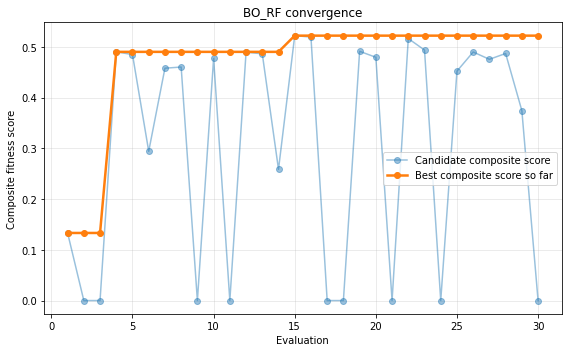

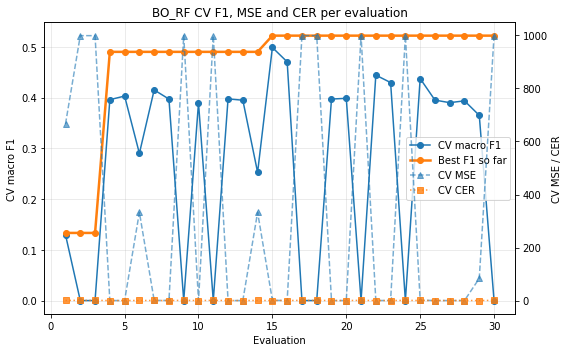

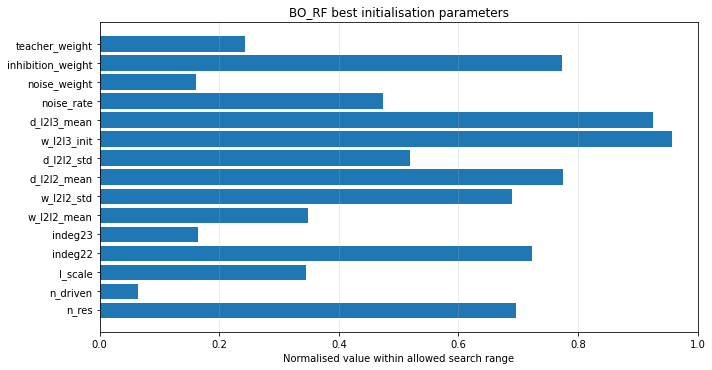

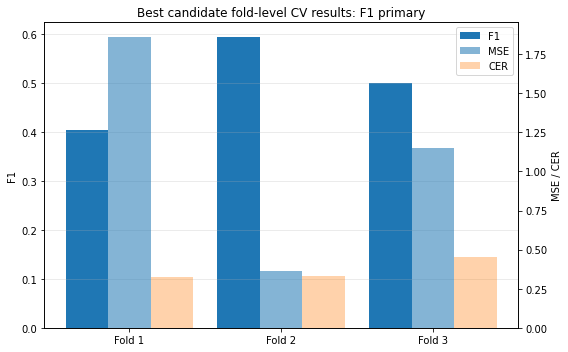

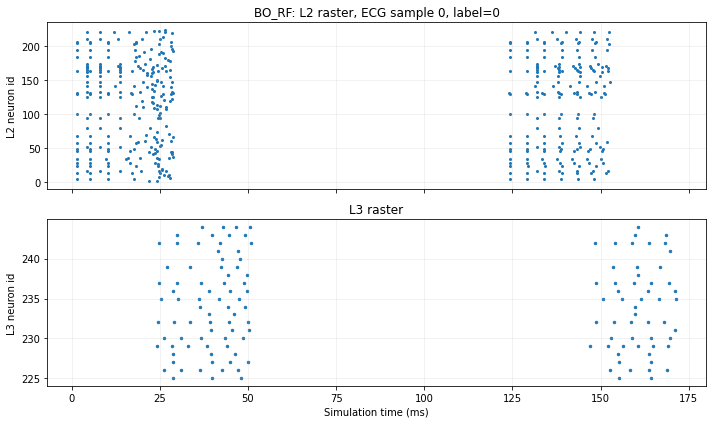

In [11]:
# ============================================================
# 11. BO — RF surrogate, auto-runnable, composite fitness
# ============================================================

def run_bo_init(n_calls=BO_CALLS, seed=SEED, n_initial=4, candidate_pool=64):
    from sklearn.ensemble import RandomForestRegressor

    rng = np.random.default_rng(seed)
    X_seen, y_seen = [], []
    history = []

    best_score = -float("inf")
    best_f1 = None
    best_mse = None
    best_cer = None
    best_params = None

    for i in range(n_calls):
        if i < n_initial or len(X_seen) < 3:
            x = random_vector(rng)
        else:
            model = RandomForestRegressor(n_estimators=50, random_state=seed+i, n_jobs=1, min_samples_leaf=1)
            model.fit(np.asarray(X_seen), np.asarray(y_seen))

            pool = np.array([random_vector(rng) for _ in range(candidate_pool)])
            pred_score = model.predict(pool)
            x = pool[int(np.argmax(pred_score))]

        print(f"\n[BO/RF] evaluation {i+1}/{n_calls}")
        score, details = evaluate_init_cv_f1(x, seed=seed+i, use_cache=True, verbose=True)
        params = vector_to_init_params(x)

        X_seen.append(x.tolist())
        y_seen.append(float(score))

        f1 = float(details.get("mean_f1", 0.0))
        mse = float(details.get("mean_mse", 999.0))
        cer = float(details.get("mean_cer", 1.0))

        if score > best_score:
            best_score = float(score)
            best_f1 = f1
            best_mse = mse
            best_cer = cer
            best_params = params

        row = {"eval": i + 1, "score": float(score), "f1": f1, "mse": mse, "cer": cer,
               "best_score_so_far": best_score, "params": params}
        history.append(row)
        checkpoint_result("BO_RF", history, best_params, best_score, best_f1, best_mse, best_cer)
        clear_memory()

    return {"optimiser": "BO_RF", "best_params": best_params,
            "best_score": best_score, "best_f1": best_f1, "best_mse": best_mse, "best_cer": best_cer,
            "history": history}

if AUTO_RUN_OPTIMISERS:
    bo_result = run_bo_init()
    save_result(bo_result, "BO_RF")
else:
    print("AUTO_RUN_OPTIMISERS=False. To run BO manually: bo_result = run_bo_init(n_calls=6)")


## 12. Genetic Algorithm Initialisation

This cell runs the GA version of the proposed initialisation method.

The GA process is:

1. Create a population of candidate LSM initialisations.
2. Evaluate each candidate using 3-fold CV macro F1.
3. Select the best candidates.
4. Apply crossover and mutation.
5. Repeat for several generations.
6. Save the best initialisation.

The GA result is saved automatically after the cell runs.


[GA] generation 1/2
  candidate 1/4
  candidate 2/4
  candidate 3/4
  candidate 4/4

[GA] generation 2/2
  candidate 1/4
  candidate 2/4
  candidate 3/4
  candidate 4/4
Saved result to: /home/ntu-user/PycharmProjects/IEEE/IEEE_6/OPT_ECG_MYINIT_3FOLD_MEMORY_SAFE_AUTORUN/GA

GA FINISHED
Best CV macro F1: 0.5671056034422738
Diagnostic CV CER: 0.35000000000000003
Diagnostic CV MSE: 0.8030473589897156

GA best parameters


,parameter,value,lower_bound,upper_bound
0,n_driven,50.000000,10.0,120.0
1,I_scale,3158.944761,500.0,8000.0
2,indeg22,19.000000,2.0,20.0
3,indeg23,54.000000,5.0,60.0
4,w_l2l2_mean,455.894758,20.0,580.0
5,w_l2l2_std,38.927742,0.0,200.0
6,d_l2l2_mean,9.387748,0.1,20.0
7,d_l2l2_std,0.438038,0.0,10.0
8,w_l2l3_init,106.402116,20.0,580.0
9,d_l2l3_mean,13.692674,0.1,20.0


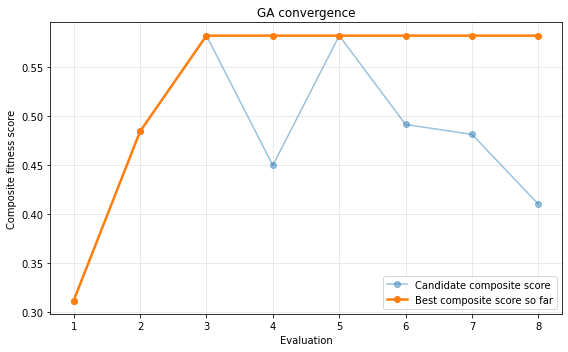

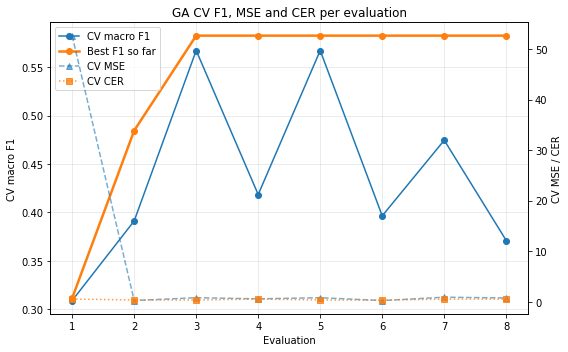

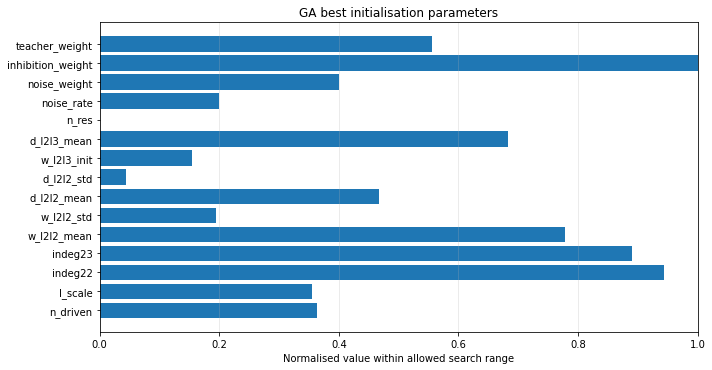

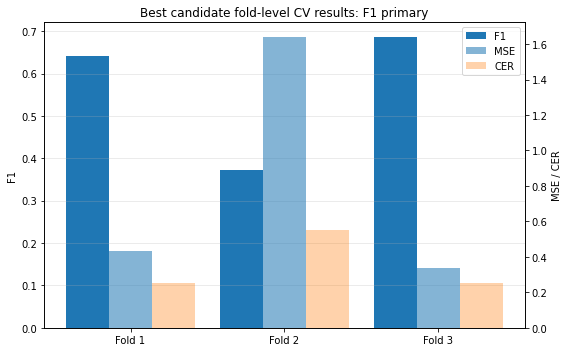

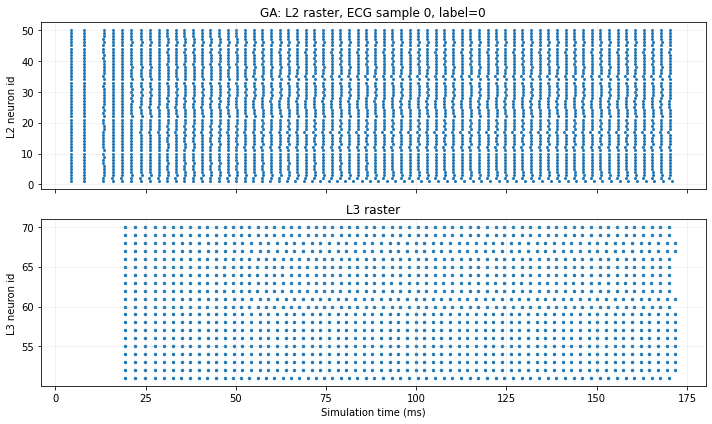

In [26]:
# ============================================================
# 12. GA — memory-safe auto-runnable, composite fitness
# ============================================================

def run_ga_init(generations=GA_GENERATIONS, pop_size=GA_POP, seed=SEED, mutation_rate=0.25, elite_frac=0.5):
    rng = np.random.default_rng(seed)
    lo = BOUNDS_ARRAY[:, 0]
    hi = BOUNDS_ARRAY[:, 1]
    dim = len(PARAM_NAMES)

    pop = np.array([random_vector(rng) for _ in range(pop_size)])
    history = []
    best_score = -float("inf")
    best_f1 = None
    best_mse = None
    best_cer = None
    best_params = None

    for gen in range(generations):
        print(f"\n[GA] generation {gen+1}/{generations}")
        scores = []

        for j, x in enumerate(pop):
            print(f"  candidate {j+1}/{pop_size}")
            score, details = evaluate_init_cv_f1(x, seed=seed + gen*100 + j, use_cache=True, verbose=False)
            scores.append(score)

            params = vector_to_init_params(x)
            f1 = float(details.get("mean_f1", 0.0))
            mse = float(details.get("mean_mse", 999.0))
            cer = float(details.get("mean_cer", 1.0))

            if score > best_score:
                best_score = float(score)
                best_f1 = f1
                best_mse = mse
                best_cer = cer
                best_params = params

            history.append({"generation": gen + 1, "candidate": j + 1, "score": float(score),
                            "f1": f1, "mse": mse, "cer": cer,
                            "best_score_so_far": best_score, "params": params})
            checkpoint_result("GA", history, best_params, best_score, best_f1, best_mse, best_cer)
            clear_memory()

        scores = np.array(scores)
        elite_n = max(2, int(math.ceil(pop_size * elite_frac)))
        elite_idx = np.argsort(scores)[::-1][:elite_n]  # maximise composite score
        elites = pop[elite_idx]

        new_pop = [elites[0].copy()]
        while len(new_pop) < pop_size:
            p1, p2 = elites[rng.integers(0, elite_n)], elites[rng.integers(0, elite_n)]
            mask = rng.random(dim) < 0.5
            child = np.where(mask, p1, p2)

            mut = rng.random(dim) < mutation_rate
            noise = rng.normal(0, 0.15, dim) * (hi - lo)
            child = np.where(mut, child + noise, child)
            child = np.clip(child, lo, hi)
            new_pop.append(child)

        pop = np.array(new_pop)

    return {"optimiser": "GA", "best_params": best_params,
            "best_score": best_score, "best_f1": best_f1, "best_mse": best_mse, "best_cer": best_cer,
            "history": history}

if AUTO_RUN_OPTIMISERS:
    ga_result = run_ga_init()
    save_result(ga_result, "GA")
else:
    print("AUTO_RUN_OPTIMISERS=False. To run GA manually: ga_result = run_ga_init()")


## 13. Evolution Strategy Initialisation

This cell runs the ES version of the proposed initialisation method.

The ES process samples candidate initialisations around a current search distribution, evaluates them using 3-fold CV macro F1, then moves the distribution toward stronger candidates.

The ES result is saved automatically after the cell runs.


[ES] generation 1/2
  candidate 1/4
  candidate 2/4
  candidate 3/4
  candidate 4/4

[ES] generation 2/2
  candidate 1/4
  candidate 2/4
  candidate 3/4
  candidate 4/4
Saved result to: /home/ntu-user/PycharmProjects/IEEE/IEEE_6/OPT_ECG_MYINIT_3FOLD_MEMORY_SAFE_AUTORUN/ES

ES FINISHED
Best CV macro F1: 0.0
Diagnostic CV CER: 1.0
Diagnostic CV MSE: 999.0

ES best parameters


,parameter,value,lower_bound,upper_bound
0,n_driven,50.000000,10.0,120.0
1,I_scale,2300.029801,500.0,8000.0
2,indeg22,14.000000,2.0,20.0
3,indeg23,45.000000,5.0,60.0
4,w_l2l2_mean,26.855074,20.0,580.0
5,w_l2l2_std,34.891025,0.0,200.0
6,d_l2l2_mean,10.686006,0.1,20.0
7,d_l2l2_std,4.209394,0.0,10.0
8,w_l2l3_init,297.647838,20.0,580.0
9,d_l2l3_mean,5.806106,0.1,20.0


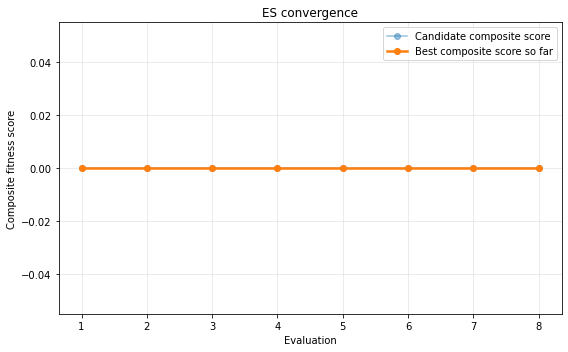

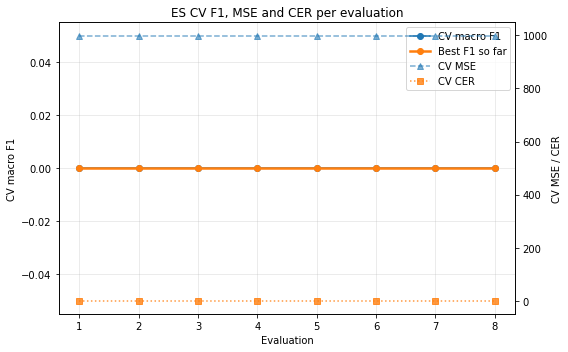

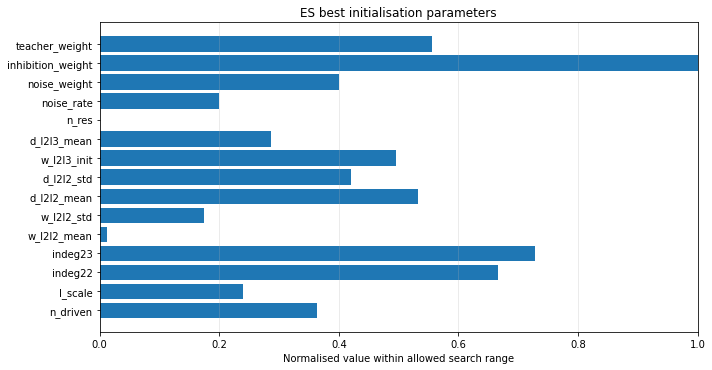

No fold-level CV results available.


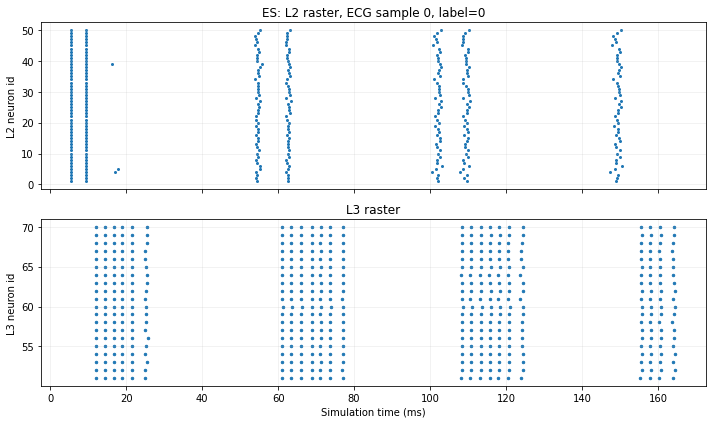

In [27]:
# ============================================================
# 13. ES — memory-safe auto-runnable, composite fitness
# ============================================================

def run_es_init(generations=ES_GENERATIONS, pop_size=ES_POP, seed=SEED, sigma=0.25):
    rng = np.random.default_rng(seed)
    lo = BOUNDS_ARRAY[:, 0]
    hi = BOUNDS_ARRAY[:, 1]
    dim = len(PARAM_NAMES)

    mean = np.full(dim, 0.5)
    history = []
    best_score = -float("inf")
    best_f1 = None
    best_mse = None
    best_cer = None
    best_params = None

    def denorm(z):
        z = np.clip(z, 0.0, 1.0)
        return lo + z * (hi - lo)

    for gen in range(generations):
        print(f"\n[ES] generation {gen+1}/{generations}")
        eps = rng.normal(0, sigma, size=(pop_size, dim))
        candidates_z = np.clip(mean + eps, 0.0, 1.0)

        scores = []
        for j, z in enumerate(candidates_z):
            print(f"  candidate {j+1}/{pop_size}")
            x = denorm(z)
            score, details = evaluate_init_cv_f1(x, seed=seed + gen*100 + j, use_cache=True, verbose=False)
            scores.append(score)

            params = vector_to_init_params(x)
            f1 = float(details.get("mean_f1", 0.0))
            mse = float(details.get("mean_mse", 999.0))
            cer = float(details.get("mean_cer", 1.0))

            if score > best_score:
                best_score = float(score)
                best_f1 = f1
                best_mse = mse
                best_cer = cer
                best_params = params

            history.append({"generation": gen + 1, "candidate": j + 1, "score": float(score),
                            "f1": f1, "mse": mse, "cer": cer,
                            "best_score_so_far": best_score, "params": params})
            checkpoint_result("ES", history, best_params, best_score, best_f1, best_mse, best_cer)
            clear_memory()

        scores = np.array(scores)
        elite_n = max(2, pop_size // 2)
        elite_idx = np.argsort(scores)[::-1][:elite_n]  # maximise composite score
        mean = candidates_z[elite_idx].mean(axis=0)
        sigma = max(0.05, sigma * 0.9)

    return {"optimiser": "ES", "best_params": best_params,
            "best_score": best_score, "best_f1": best_f1, "best_mse": best_mse, "best_cer": best_cer,
            "history": history}

if AUTO_RUN_OPTIMISERS:
    es_result = run_es_init()
    save_result(es_result, "ES")
else:
    print("AUTO_RUN_OPTIMISERS=False. To run ES manually: es_result = run_es_init()")


## 14. Compare BO, GA, and ES Results

This section compares the three optimisation methods using the **composite score** as the search objective.

The plots still show F1, CER, and MSE so you can see whether the selected parameters are improving the metrics you care about.


Comparison table:


,optimiser,best_composite_score,best_cv_f1,best_cv_cer,best_cv_mse,n_res,n_driven,I_scale,indeg22,indeg23
0,BO_RF,0.522195,0.498836,0.370469,1.122965,224,17,3084.871491,15,14
1,GA,0.508252,0.408688,0.300000,0.216982,251,116,2662.460779,9,13
2,ES,0.000000,0.000000,1.000000,999.000000,50,50,2300.029801,14,45


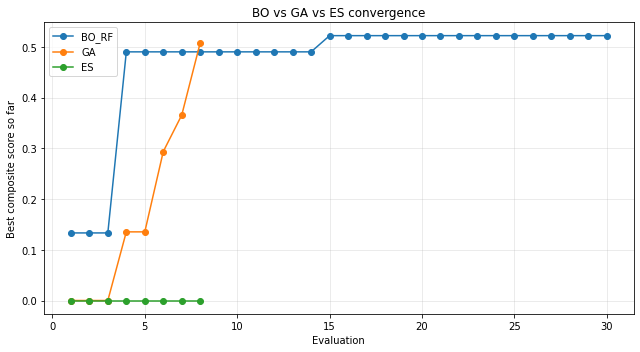

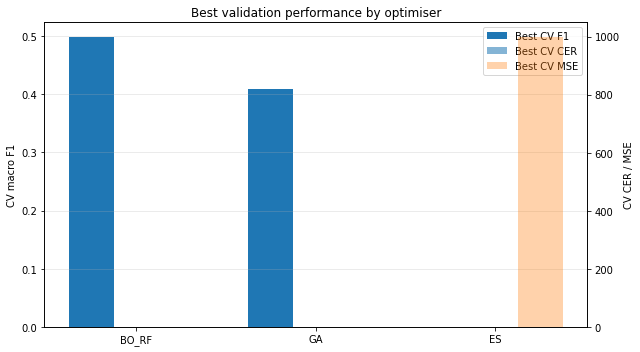

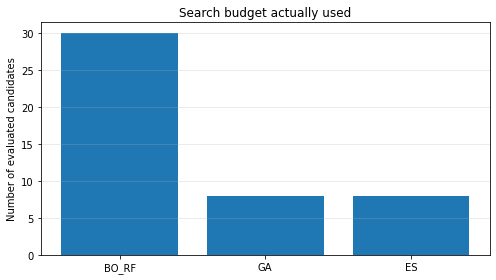

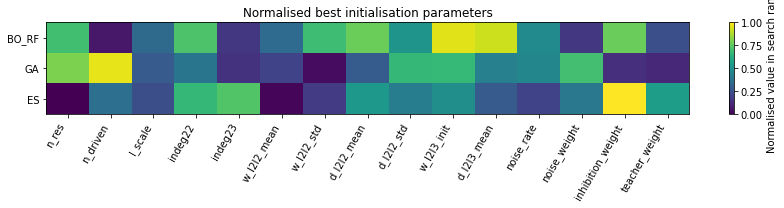

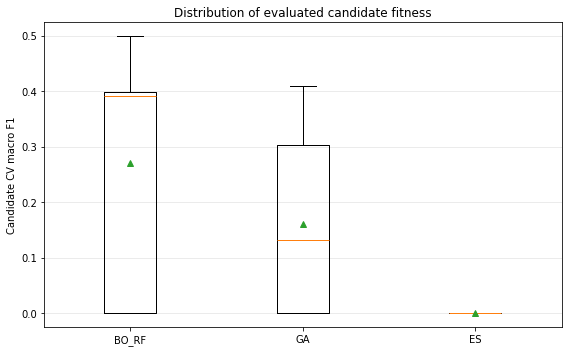

All outputs saved in: /home/ntu-user/PycharmProjects/IEEE/IEEE_6/OPT_ECG_MYINIT_3FOLD_MEMORY_SAFE_AUTORUN


In [13]:
# ============================================================
# 14. Compare BO vs GA vs ES — multiple comparison plots, F1-primary
# ============================================================

def load_saved_result(name):
    base = OUTPUT_ROOT / name
    p = base / "best_init_params.json"
    hp = base / "fitness_history.json"
    if not p.exists():
        return None
    d = json.loads(p.read_text())
    hist = json.loads(hp.read_text()) if hp.exists() else []
    return {"name": name, "summary": d, "history": hist, "dir": base}

saved = [r for r in [load_saved_result(n) for n in ["BO_RF", "GA", "ES"]] if r is not None]

results = []
for r in saved:
    d = r["summary"]
    row = {
        "optimiser": r["name"],
        "best_composite_score": d.get("best_composite_score"),
        "best_cv_f1": d.get("best_cv_f1"),
        "best_cv_cer": d.get("best_cv_cer"),
        "best_cv_mse": d.get("best_cv_mse"),
    }
    row.update({k: d["init_params"].get(k) for k in ["n_res", "n_driven", "I_scale", "indeg22", "indeg23"]})
    results.append(row)

print("Comparison table:")
if PANDAS_AVAILABLE and results:
    display(pd.DataFrame(results))
else:
    for r in results:
        print(r)

(OUTPUT_ROOT / "comparison_results.json").write_text(json.dumps(results, indent=2))

# Plot 1: convergence curves — best F1 so far
plt.figure(figsize=(9, 5))
for r in saved:
    hist = r["history"]
    if hist:
        x, scores, best, f1s, mses, cers = _history_best_curve(hist)
        plt.plot(x, best, marker="o", label=r["name"])
plt.xlabel("Evaluation")
plt.ylabel("Best composite score so far")
plt.title("BO vs GA vs ES convergence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "comparison_convergence_composite.png", dpi=220)
plt.savefig(OUTPUT_ROOT / "comparison_convergence_composite.pdf")
plt.show()

# Plot 2: best CV F1, CER, MSE bars
if results:
    names = [r["optimiser"] for r in results]
    f1_vals = [r["best_cv_f1"] for r in results]
    cer_vals = [r["best_cv_cer"] for r in results]
    mse_vals = [r["best_cv_mse"] for r in results]
    x = np.arange(len(names))
    width = 0.25
    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax1.bar(x - width, f1_vals, width, label="Best CV F1")
    ax1.set_ylabel("CV macro F1")
    ax1.set_xticks(x)
    ax1.set_xticklabels(names)
    ax2 = ax1.twinx()
    ax2.bar(x, cer_vals, width, alpha=0.55, label="Best CV CER")
    ax2.bar(x + width, mse_vals, width, alpha=0.35, label="Best CV MSE")
    ax2.set_ylabel("CV CER / MSE")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
    ax1.set_title("Best validation performance by optimiser")
    ax1.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / "comparison_best_f1_cer_mse.png", dpi=220)
    plt.savefig(OUTPUT_ROOT / "comparison_best_f1_cer_mse.pdf")
    plt.show()

# Plot 3: number of evaluated candidates per optimiser
if saved:
    names = [r["name"] for r in saved]
    eval_counts = [len(r["history"]) for r in saved]
    plt.figure(figsize=(7, 4))
    plt.bar(names, eval_counts)
    plt.ylabel("Number of evaluated candidates")
    plt.title("Search budget actually used")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / "comparison_eval_counts.png", dpi=220)
    plt.savefig(OUTPUT_ROOT / "comparison_eval_counts.pdf")
    plt.show()

# Plot 4: normalised selected parameters heatmap
if saved:
    all_param_names = list(INIT_PARAM_BOUNDS_FULL.keys())
    mat = []
    names = []
    for r in saved:
        params = r["summary"].get("init_params", {})
        mat.append([_normalise_param_value(p, params.get(p, np.nan)) for p in all_param_names])
        names.append(r["name"])
    mat = np.array(mat, dtype=float)
    fig, ax = plt.subplots(figsize=(12, max(3, 0.55 * len(names))))
    im = ax.imshow(mat, aspect="auto", vmin=0, vmax=1)
    ax.set_yticks(np.arange(len(names)))
    ax.set_yticklabels(names)
    ax.set_xticks(np.arange(len(all_param_names)))
    ax.set_xticklabels(all_param_names, rotation=60, ha="right")
    ax.set_title("Normalised best initialisation parameters")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Normalised value in search range")
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / "comparison_parameter_heatmap.png", dpi=220)
    plt.savefig(OUTPUT_ROOT / "comparison_parameter_heatmap.pdf")
    plt.show()

# Plot 5: candidate F1 distribution per optimiser
plt.figure(figsize=(8, 5))
box_data, box_names = [], []
for r in saved:
    hist = r["history"]
    vals = [float(h.get("f1", np.nan)) for h in hist if np.isfinite(float(h.get("f1", np.nan)))]
    if vals:
        box_data.append(vals)
        box_names.append(r["name"])
if box_data:
    plt.boxplot(box_data, labels=box_names, showmeans=True)
    plt.ylabel("Candidate CV macro F1")
    plt.title("Distribution of evaluated candidate fitness")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / "comparison_candidate_f1_distribution.png", dpi=220)
    plt.savefig(OUTPUT_ROOT / "comparison_candidate_f1_distribution.pdf")
    plt.show()

print("All outputs saved in:", OUTPUT_ROOT)


## 15. Notes on Memory Safety and Final Evaluation

This section summarises how to run the notebook safely.

Recommended workflow:

1. Start with `FAST_MODE=True`.
2. Run the notebook cell-by-cell.
3. If RAM usage becomes high, restart the kernel.
4. Cached fitness values and checkpoint files will preserve progress.
5. After the optimiser results are saved, use the best initialisation for final full training.

Final reporting should use CER, accuracy, macro F1, and confusion matrix. For publication-style results, repeat the final run across multiple seeds and report mean ± standard deviation.

## Notes

If RAM still crashes:

1. Restart the kernel.
2. Keep `FAST_MODE = True`.
3. Run only one optimiser cell at a time, even though auto-run is enabled.
4. Reduce `BO_CALLS`, `GA_POP`, `ES_POP`, or `MAX_TRAIN_SEQS_FOR_OPT`.
5. Keep using the cache folder; repeated candidate evaluations will be loaded from disk.
6. If you get a permission error, check the printed `OUTPUT_ROOT`; this notebook automatically falls back to a writable folder such as your home directory or `/tmp`.